# Building an Object-Detection Training Set from Videos

This demo turns raw videos into a PyTorch-ready object-detection training set with a declarative Pixeltable schema.

```
videos (table)       source videos + metadata
  -> frames (view)   one frame per second + YOLOX pseudo-labels
  -> training_frames frames with detections, resized to 640x640
```

Install the project once with `uv sync`, then run this notebook with `uv run jupyter lab`.

## Create the schema

The pipeline lives in `schema.py`. `pxt schema update` creates missing tables and updates existing ones.

In [1]:
from pathlib import Path

print(Path("schema.py").read_text())

"""Pixeltable schema for building an object-detection training set from videos.

Hierarchy:
    videos (table)            source videos + metadata
    -> frames (view)          one row per extracted frame (frame_iterator, 1 fps), YOLOX detections
    -> training_frames (view) frames with at least one detection, resized to the model input size,
                              with bounding boxes rescaled to match

Create or update the schema with:
    pxt schema update schema.py od_demo
"""

import pixeltable as pxt
import pixeltable.functions as pxtf
from pixeltable.catalog.model import Column

TableModel = pxt.model_base()

# Model input size (square); boxes are rescaled to this canvas.
IMG_SIZE = 640

B2_BASE = "https://s3.us-west-004.backblazeb2.com/ai-campfire/od-training-demo/"
B2_FRAMES_OVERLAY_DEST = f"{B2_BASE}frame-overlays/"
B2_TRAINING_OVERLAY_DEST = f"{B2_BASE}training-overlays/"


class Videos(TableModel, name="videos"):
    """Source videos; insert local files or S3/HTTP UR

In [2]:
!uv run pxt schema update schema.py od_demo

exists   od_demo/videos
exists   od_demo/frames
exists   od_demo/training_frames


In [3]:
import pixeltable as pxt

videos = pxt.get_table("od_demo.videos")
frames = pxt.get_table("od_demo.frames")
training_frames = pxt.get_table("od_demo.training_frames")

Connected to Pixeltable database at: postgresql+psycopg://postgres:@/pixeltable?host=/Users/alison-pxt/.pixeltable/pgdata


/Users/alison-pxt/Documents/Github/b2-object-detection-demo/.venv/lib/python3.11/site-packages/pixeltable/env.py:330: UserWarning: Progress reporting is disabled because ipywidgets is not installed. To fix this, run: `pip install ipywidgets`
  warnings.warn(


## Insert videos

These public videos come from the [Multimedia Commons](http://mmcommons.org/) S3 bucket. Inserting them runs frame extraction, YOLOX inference, and training-sample construction.

In [4]:
S3_PREFIX = "s3://multimedia-commons/data/videos/mp4/"
video_paths = [
    "9cd/047/9cd047335f12962a5e633c3b9e6602e.mp4",
    "111/015/1110153dc81d833025828f875b3ad2.mp4",
    "888/061/8880616a157cfd9036fc16ad6cf5c3af.mp4",
    "abc/01a/abc01aa533364ca1597e0f287f393b9.mp4",
    "00a/a5b/00aa5b8cc17f67eded6a257a61119.mp4",
    "7ab/023/7ab02326a7c9ab4728681f63aaa7c36d.mp4",
]

videos.insert([{"video": S3_PREFIX + path} for path in video_paths])
print(f"{videos.count()} videos -> {frames.count()} frames -> {training_frames.count()} training samples")

objc[57378]: Class AVFFrameReceiver is implemented in both /Users/alison-pxt/Documents/Github/b2-object-detection-demo/.venv/lib/python3.11/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x11978c3a8) and /Users/alison-pxt/Documents/Github/b2-object-detection-demo/.venv/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1249d83a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[57378]: Class AVFAudioReceiver is implemented in both /Users/alison-pxt/Documents/Github/b2-object-detection-demo/.venv/lib/python3.11/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x11978c3f8) and /Users/alison-pxt/Documents/Github/b2-object-detection-demo/.venv/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1249d83f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Inserted 516 rows with 0 errors in 33.82 s (15.26 rows/s)
13 videos -> 580 frames -> 580 training samples


## Inspect the pseudo-labels

`overlay` renders the YOLOX detections on each frame and stores the result in Backblaze B2.

overlay,num_detections,detections
,10,"{""bboxes"": [[578.786, -0.145, 639.801, 266.623], [374.122, 92.576, 503.798, 330.208], [296.3, -0.45, 387.505, 161.162], [466.651, 0.751, 566.312, 247.462], [0.174, 176.1, 149.516, 356.378], [381.887, 1.601, 473.35, 145.789], [231.484, 8.851, 304.594, 181.594], [169.525, 99.761, 354.35, 355.782], [318.06, 115.933, 383.561, 279.029], [530.014, 78.586, 569.721, 166.583]], ""labels"": [0, 0, 0, 0, 0, 0, 0, 0, 0, 26], ""scores"": [0.863, 0.857, 0.833, 0.766, 0.738, 0.698, 0.666, 0.651, 0.554, 0.537]}"
,11,"{""bboxes"": [[369.864, 85.693, 504.355, 326.806], [567.296, -6.22, 640.464, 260.169], [173.133, 97.12, 347.154, 359.346], [293.373, 0.236, 385.126, 156.138], [469.876, -2.163, 570.612, 216.947], [166.176, 0.472, 237.316, 150.042], [6.034, 72.424, 282.066, 357.553], [80.241, -4.261, 175.703, 183.101], [383.649, -0.636, 478.519, 155.96], [321.299, 110.833, 381.229, 307.396], [232.231, 6.416, 301.394, 160.783]], ""labels"": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ""scores"": [0.87, 0.868, 0.855, 0.815, 0.771, 0.676, 0.648, 0.643, 0.624, 0.612, 0.61]}"

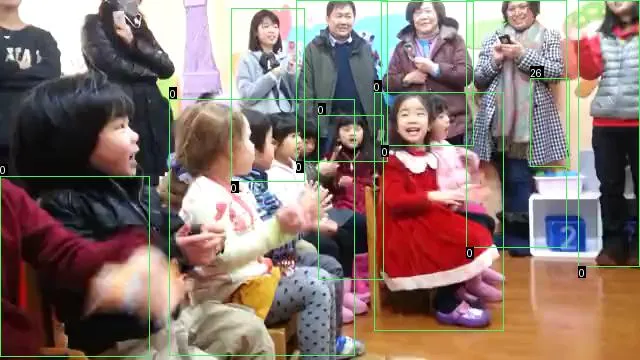
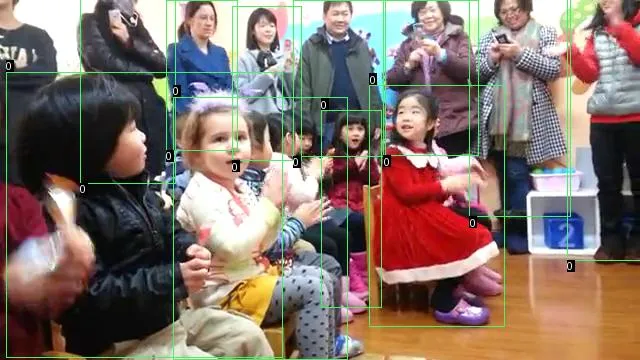

In [5]:
frames.select(frames.overlay, frames.num_detections, frames.detections).head(2)

## Incremental computation

Insert one more video. Only its new frames are processed; existing results remain untouched.

In [6]:
videos.insert([{"video": S3_PREFIX + "cde/078/cde078a6803a16cae79eb438e178f0ce.mp4"}])
print(f"{videos.count()} videos -> {frames.count()} frames -> {training_frames.count()} training samples")

Inserted 141 rows with 0 errors in 12.96 s (10.88 rows/s)
14 videos -> 650 frames -> 650 training samples


## Image transforms for detection training

Pixeltable caches deterministic preprocessing such as resizing images and boxes. Stochastic augmentation belongs in the DataLoader so it changes every epoch.

training_overlay,labels
,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 26]"
,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"

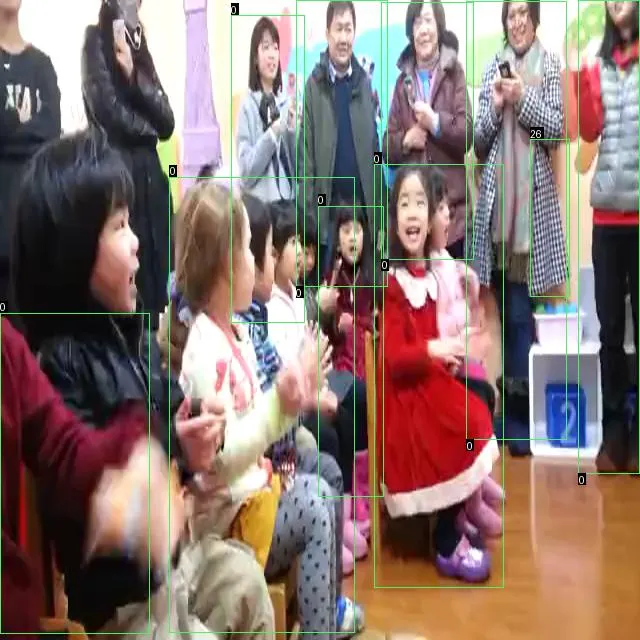
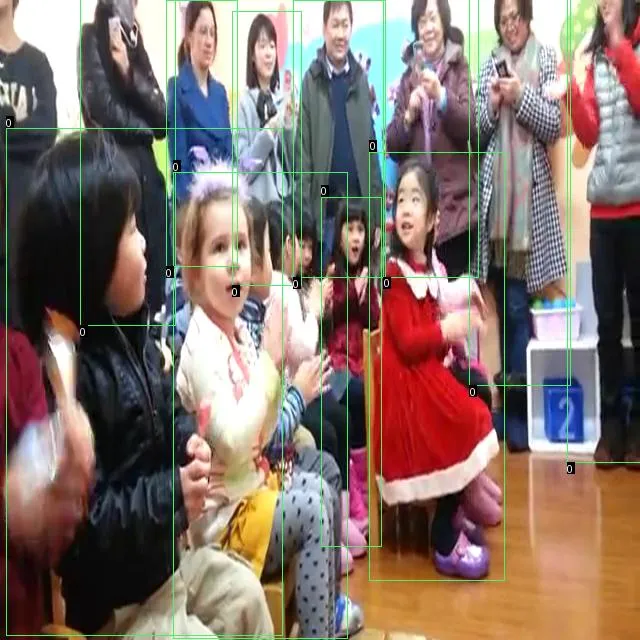

In [7]:
training_frames.select(training_frames.training_overlay, training_frames.labels).head(2)

## Export to PyTorch

`to_pytorch_dataset()` caches the query result and returns an `IterableDataset`. The custom collator handles variable-length boxes and applies stochastic augmentation.

In [14]:
import torch
from torch.utils.data import DataLoader
from torchvision import tv_tensors
from torchvision.transforms import v2

dataset = training_frames.select(
    training_frames.image, training_frames.boxes, training_frames.labels
).to_pytorch_dataset(image_format="pt")

In [15]:
dataset

In [16]:
augment = v2.RandomHorizontalFlip(p=0.5)

def collate(samples: list[dict]) -> dict:
    images, boxes, labels = [], [], []
    for sample in samples:
        bounding_boxes = tv_tensors.BoundingBoxes(
            torch.tensor(sample["boxes"], dtype=torch.float32),
            format="XYXY",
            canvas_size=(640, 640),
        )
        image, bounding_boxes = augment(sample["image"], bounding_boxes)
        images.append(image)
        boxes.append(torch.as_tensor(bounding_boxes))
        labels.append(torch.tensor(sample["labels"], dtype=torch.int64))
    return {"images": torch.stack(images), "boxes": boxes, "labels": labels}

loader = DataLoader(dataset, batch_size=8, collate_fn=collate)
batch = next(iter(loader))
print("images:", batch["images"].shape, batch["images"].dtype)
print("boxes[0]:", batch["boxes"][0].shape)
print("labels[0]:", batch["labels"][0].shape)

images: torch.Size([8, 3, 640, 640]) torch.float32
boxes[0]: torch.Size([10, 4])
labels[0]: torch.Size([10])


## Where to go from here

- Export the same data as COCO JSON with `to_coco_dataset()`.
- Add an embedding index to curate more frames like a hard example.
- Label with a larger model and evaluate a smaller model against it.